In [1]:
import numpy as np
import particles_cdssm.sdes as sdes
import particles_cdssm.continuous_discrete_ssms as cdssms
import matplotlib.pyplot as plt
from cdssm_lib import CDSSM_LIB
import arviz as az
import dill

plt.style.use('ggplot')

# Pilot particle filter runs:

The goal of this notebook is to determine at what discretisation level for the FHN model does the particle filter work well: once we have this information, we can generate our first set of results that are correct for our choice of model, and then decide whether we want to extend it further. We try to make the code generic so that it is theoretically applicable to any given model:

In [2]:
from cdssm_lib import CDSSM_LIB
from particles_cdssm.tools import build_cdssm

delta_t_vals = [0.005, 0.01, 0.02, 0.05, 0.1]
T=100; num=1000

load_data = True

cdssm = build_cdssm(CDSSM_LIB['ifhn'])
cdssm.s_ts = delta_t_vals[-1]
S = cdssm.s_ts * T

# Simulate the data 
x, _ = cdssm.simulate(T=T, num=num)

# Alternative: load the data
if load_data:
    run_id=20
    with open(f'./results/run_{run_id}_meta.pkl', 'rb') as f:
        metadata = dill.load(f)
    x = metadata['x']

sde_paths = np.concatenate([np.concatenate([x[i][name] for name in x[0].dtype.names]) for i in range(T)])
sim_times = np.linspace(start=0., stop=S, num=(sde_paths.shape[0] + 1))[1:]

delta_s = delta_t_vals[-1]/num
subs_rates = [int(delta_t/delta_s) for delta_t in delta_t_vals]

def gen_obsvns(subs_rate):
    subs_paths = sde_paths[(subs_rate - 1)::subs_rate]
    n_obs = subs_paths.shape[0]
    observations = [cdssm.PY(t, None, subs_paths[t]).rvs() for t in range(n_obs)]
    return observations

observations_list = [gen_obsvns(subs_rate) for subs_rate in subs_rates]
if load_data:
    observations_list[-1] = metadata['y'] 
arr_observations_list = [np.array([obs[0][0] for obs in obs_list]) for obs_list in observations_list]

# The Dataset: this is what we are trying to infer

We present below the FHN model that defines our CD-SSM for this experiment:

\begin{align}
dV_t &= Z_t dt \\
dZ_t &= \frac{1}{\epsilon}(1-\epsilon - 3V_t^2)Z_t dt + \frac{1}{\epsilon}\Big[(1-\gamma)V_t - V_t^3  - (s+\beta)\Big]dt - \frac{\sigma}{\epsilon} dB_t
\end{align}


We have used the following parameter values:

In [3]:
cdssm.params

{'epsilon': 0.1,
 'gamma': 1.5,
 'beta': 0.8,
 'sigma_u': 0.3,
 'G': array([[1., 0.]]),
 'covY': array([[0.0001]])}

We need to resolve the following key problems:
    
- The bridges within the particle filters do not appear to be working properly: look at this and try to diagnose and solve the problem.
- Once you have them working, you may also have issues with the choice of proposal: in particular, the proposal for the ending point might be naive. 
- Finally, you need to optimise the hyperparameters: it should be the case that they are set to reasonable values such that the difference between introducing the transform and not having the transform is clear.

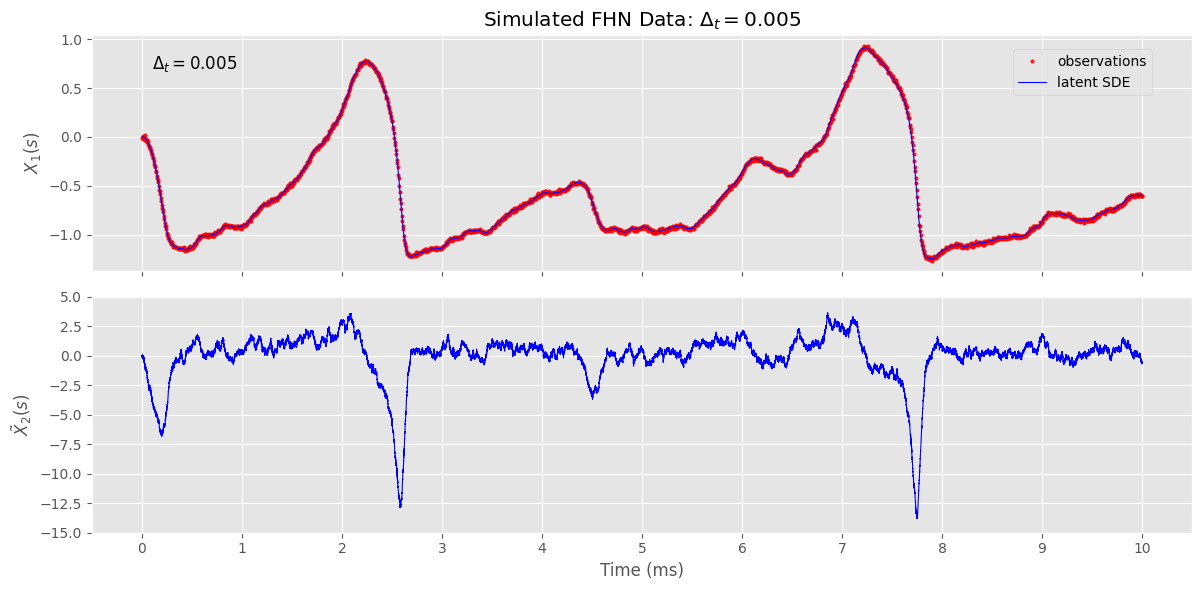

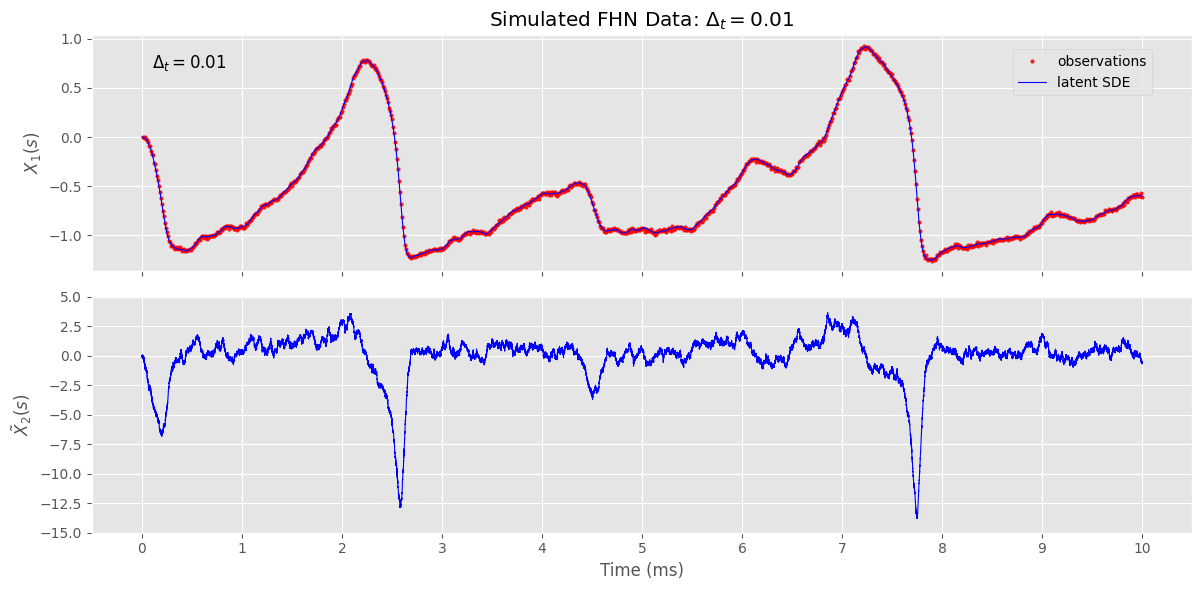

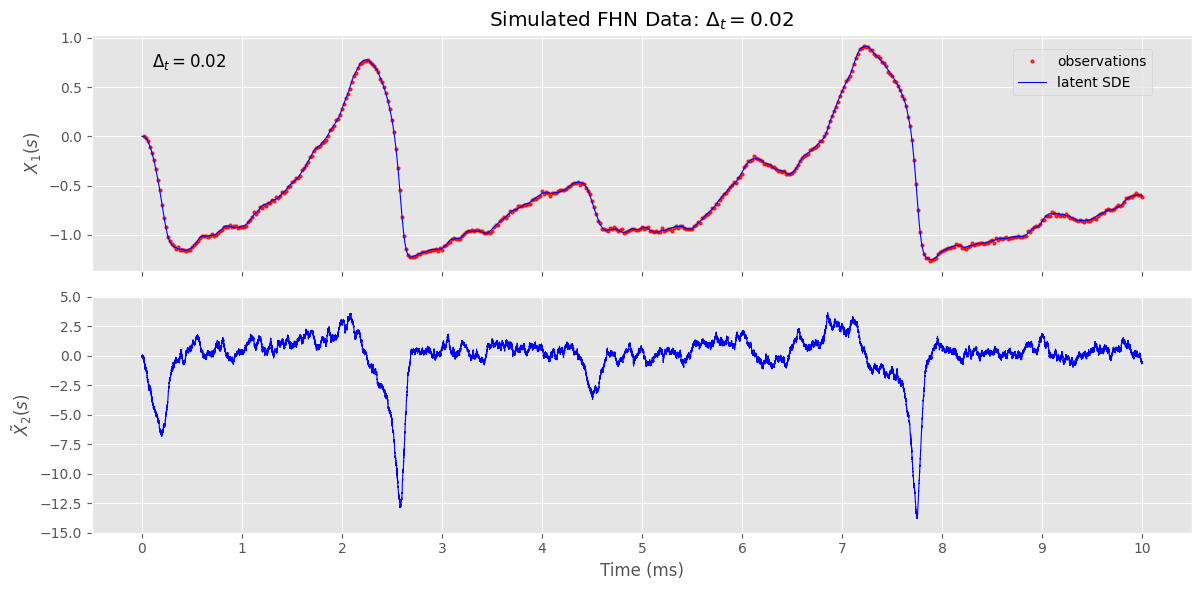

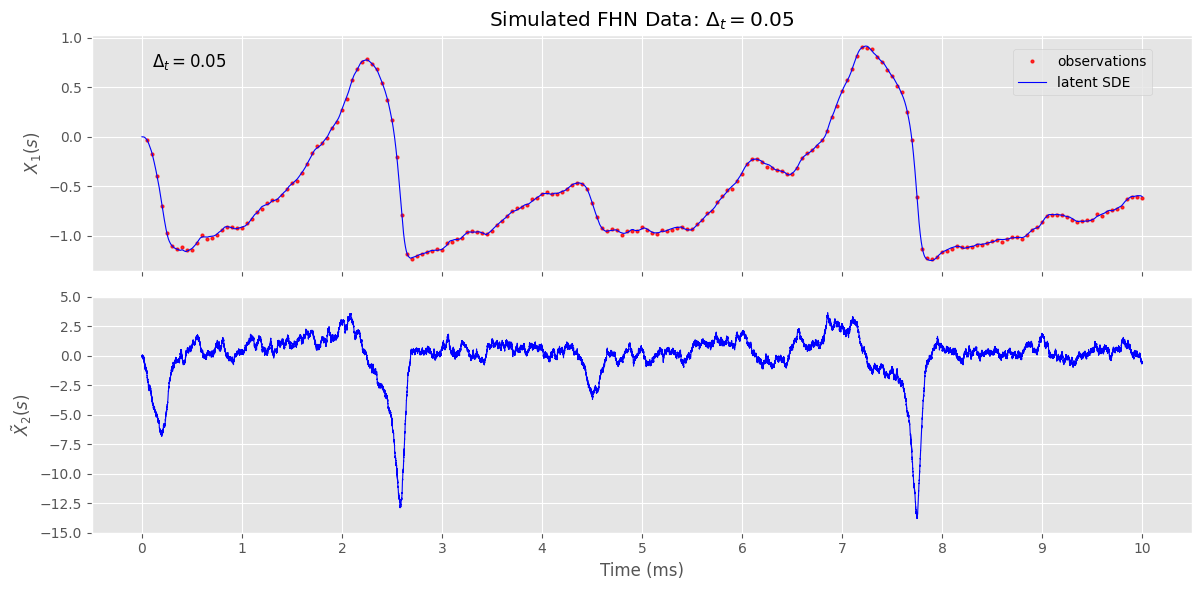

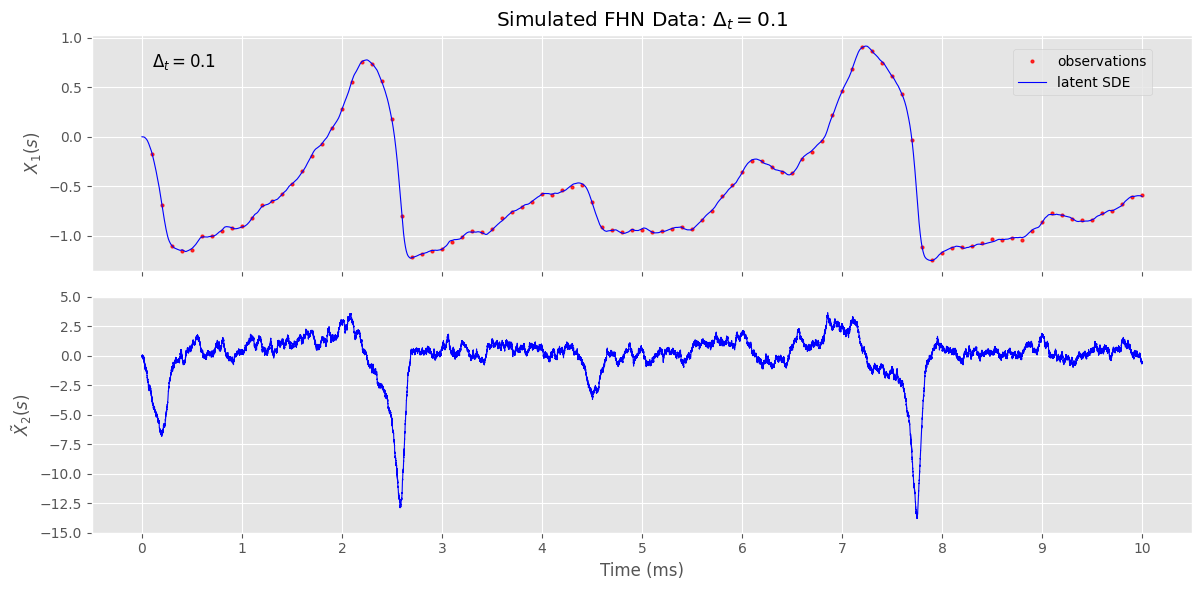

In [25]:
for subs_rate, delta_t, obsvns in zip(subs_rates, delta_t_vals, arr_observations_list):
    
    obs_times = sim_times[(subs_rate - 1)::subs_rate]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    labels = [r'$X_1(s)$', r'$\tilde{X}_2(s)$']

    # # chain_vals = icsmc_reparameterised.posterior['x'].values # (8, 1000, 100, 2)
    # # chain_vals = np.concatenate([chain_vals[i] for i in range(8)], axis=0)
    # mean_vals = chain_vals.mean(axis=0)
    # quantile_vals = np.quantile(chain_vals, axis=0, q=[0.05, 0.95])

    axes[0].plot(obs_times, obsvns, 'o', markersize=2.0, color='red', alpha=0.8, label='observations')

    for i, ax in enumerate(axes):
        ax.plot(sim_times, sde_paths[:, i], color='blue', linewidth=0.8, linestyle='-', marker=None, label='latent SDE')
        # ax.plot(obs_times, mean_vals[:, i], color='green', linewidth=0.8, linestyle='-', marker=None, label='BwG-iCSMC-BS')
        # ax.plot(obs_times, quantile_vals[0, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6, label='95% C.I')
        # ax.plot(obs_times, quantile_vals[1, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6)
        ax.set_ylabel(labels[i])

    axes[0].set_title('Simulated FHN Data: '+ r'$\Delta_t =$' + str(delta_t))
    axes[0].text(0.1, 0.7, r'$\Delta_t =$' + str(delta_t), fontsize=12)
    axes[0].legend(loc='upper right', bbox_to_anchor=(0.97, 0.97))

    axes[-1].set_xlabel('Time (ms)')
    axes[-1].set_xticks([float(i) for i in range(11)])
    axes[-1].set_ylim((-15.0, 5.0))

    # axes[-1].set_xlim((0, 1.5))
    # axes[-1].set_ylim((-5.0, 5.0))
    plt.tight_layout()

    if delta_t == 0.05:
        plt.savefig('fhn_data.png', dpi=300) 

    plt.show()

# Particle Filter runs for each value of $\Delta_t$

In [5]:
from cdssm_lib import CDSSM_LIB
import particles_cdssm.feynman_kac as sfk
import particles_cdssm.auxiliary_bridges as axb
from particles_cdssm import CDSSM_SMC

smc_kwargs = dict(N=100, store_history=True, num=50)

cdssms = []

bootstrap_fks = []
guided_fks = []
bootstrap_algs = []
guided_algs = []

ifhn = CDSSM_LIB['ifhn']

for y, s_t in zip(observations_list, delta_t_vals):
    ifhn['cdssm_params']['s_ts'] = s_t
    cdssm = build_cdssm(ifhn)
    cdssms.append(cdssm)
    
    cd_boot_fk = sfk.BootstrapDA(cdssm=cdssm, data=y)
    cd_fk = sfk.BackwardGuidedDA(cdssm=cdssm, data=y, 
                                 auxiliary_bridge_cls=axb.IntegratedDriftBrownianAuxBridge, 
                                 end_pt_proposal_cls=axb.IntegratedDriftBrownianEndPointProposal)

    bootstrap_fks.append(cd_boot_fk)
    guided_fks.append(cd_fk)

    boot_alg = CDSSM_SMC(cd_boot_fk, **smc_kwargs)
    guided_alg = CDSSM_SMC(cd_fk, **smc_kwargs)

    bootstrap_algs.append(boot_alg)
    guided_algs.append(guided_alg)
    
for delta_t, alg in zip(delta_t_vals, bootstrap_algs):
    print(f'Running bootstrap pf for delta_t = {delta_t}:')
    alg.run()
    print(f'Run complete - time: {alg.cpu_time} s')

Running bootstrap pf for delta_t = 0.005:
Run complete - time: 3.8176487080054358 s
Running bootstrap pf for delta_t = 0.01:
Run complete - time: 1.8181833329726942 s
Running bootstrap pf for delta_t = 0.02:
Run complete - time: 0.8888685420388356 s
Running bootstrap pf for delta_t = 0.05:
Run complete - time: 0.3543373750289902 s
Running bootstrap pf for delta_t = 0.1:
Run complete - time: 0.17815366602735594 s


In [ ]:
for delta_t, alg in zip(delta_t_vals, guided_algs):
    print(f'Running guided pf for delta_t = {delta_t}:')
    alg.run()
    print(f'Run complete - time: {alg.cpu_time} s')

Running guided pf for delta_t = 0.005:
Run complete - time: 83.42048545897705 s
Running guided pf for delta_t = 0.01:
Run complete - time: 43.90773141698446 s
Running guided pf for delta_t = 0.02:
Run complete - time: 23.03025566600263 s
Running guided pf for delta_t = 0.05:
Run complete - time: 8.455722249986138 s
Running guided pf for delta_t = 0.1:
Run complete - time: 4.259885833016597 s


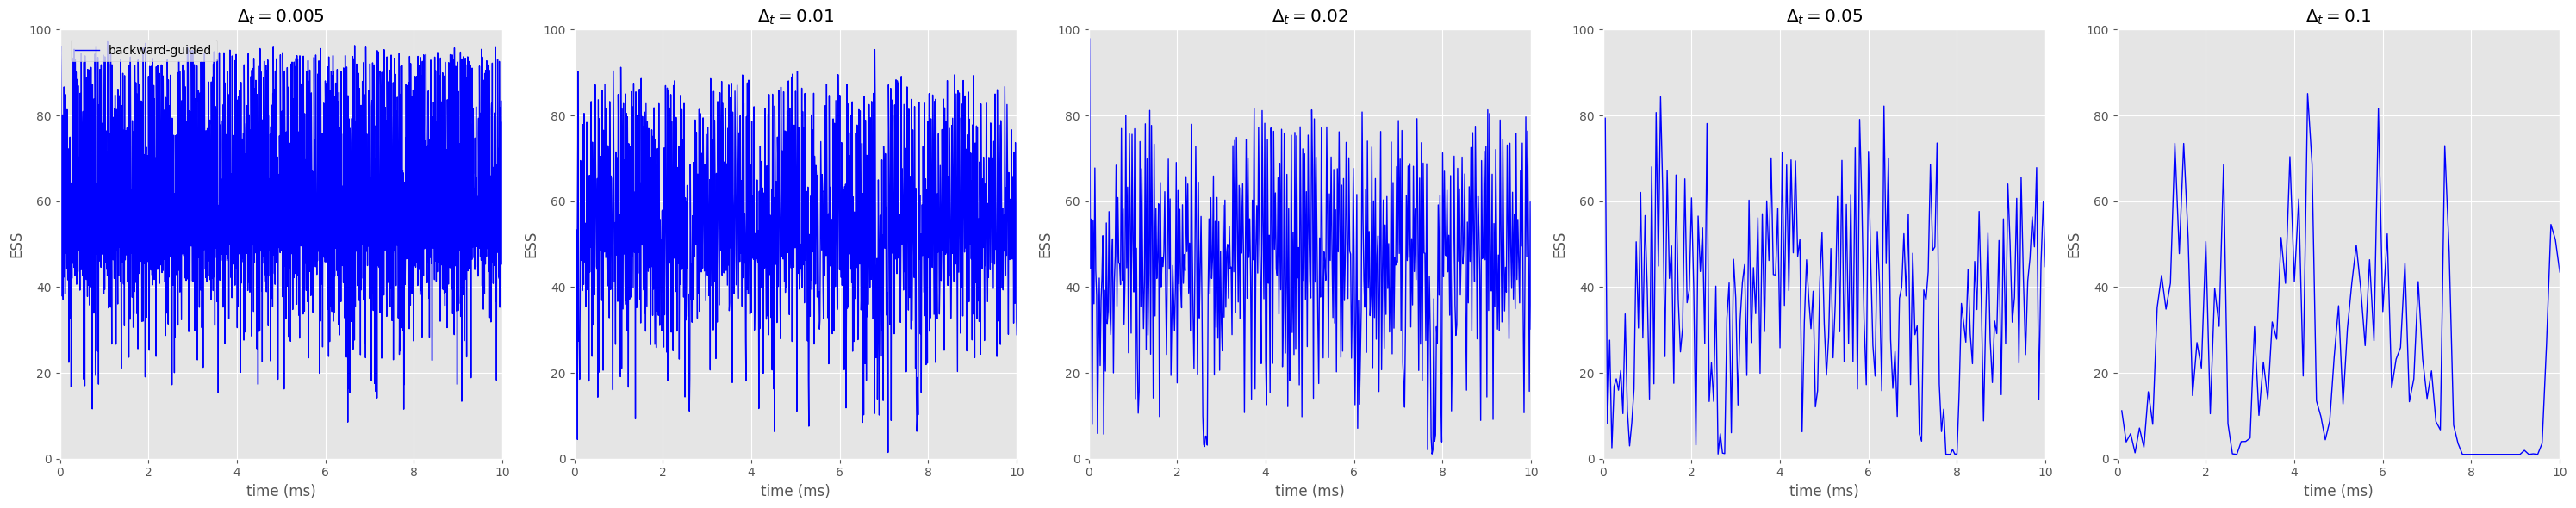

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

for i, ax in enumerate(axes):
    subs_rate = subs_rates[i]
    x = sim_times[(subs_rate - 1)::subs_rate]
    y = guided_algs[i].summaries.ESSs
    ax.plot(x, guided_algs[i].summaries.ESSs, color='blue', linewidth=1.0, linestyle='-', alpha=1.0, label='backward-guided')
    ax.plot(x, bootstrap_algs[i].summaries.ESSs, color='red', linewidth=1.0, linestyle='-', alpha=1.0, label='bootstrap')
    ax.set(xlim=(0, 10), ylim=(0, 100), xlabel='time (ms)', ylabel='ESS', title=r'$\Delta_t = $' + str(delta_t_vals[i]))

axes[0].legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))

plt.tight_layout()
plt.savefig('ESS_plot.png')

plt.show()

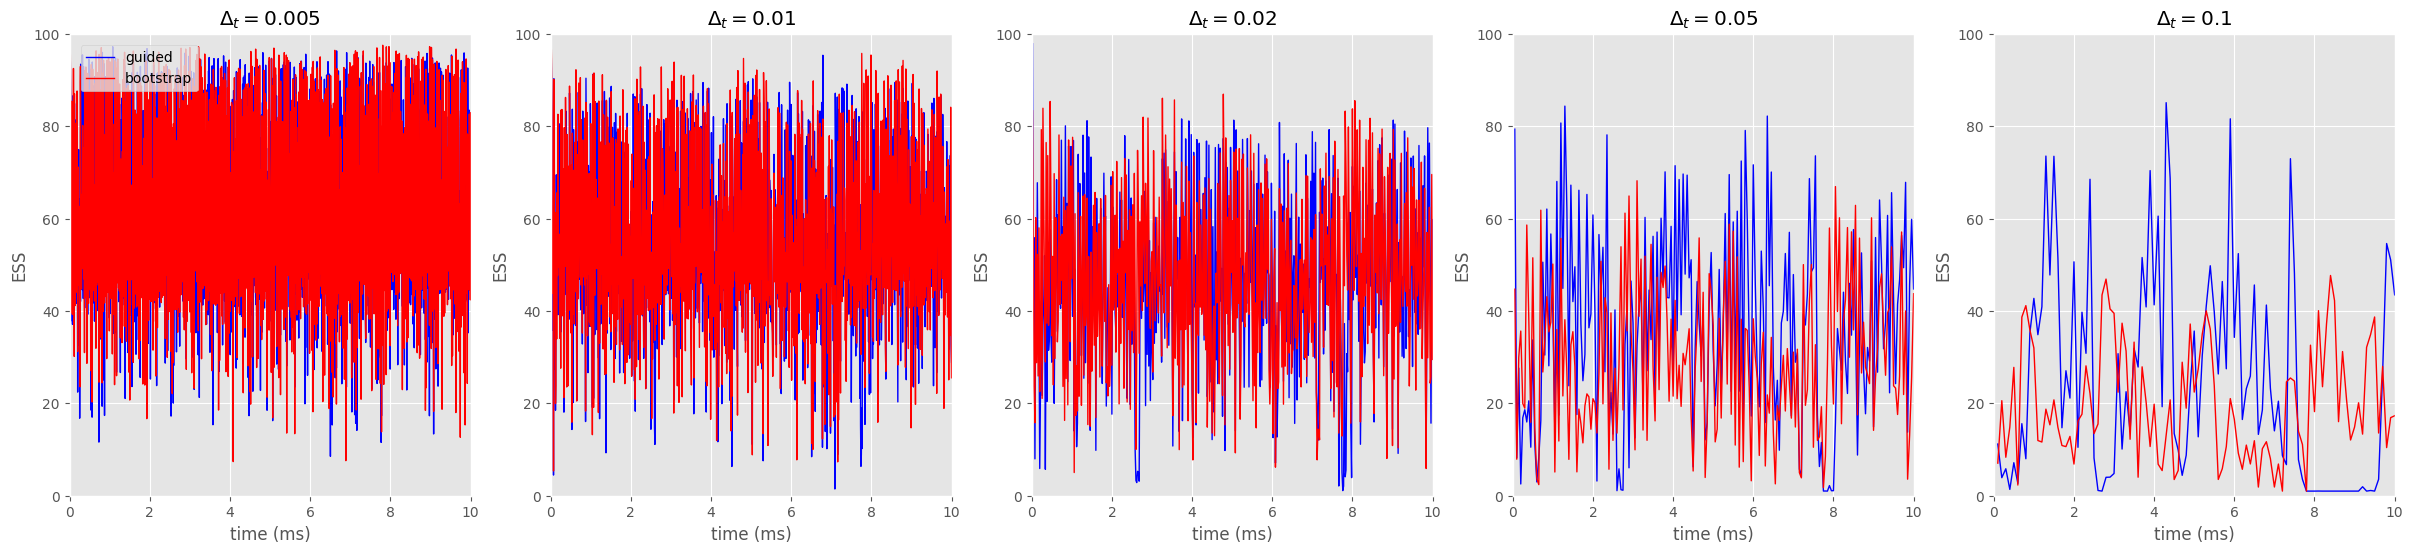

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

for i, ax in enumerate(axes):
    subs_rate = subs_rates[i]
    x = sim_times[(subs_rate - 1)::subs_rate]
    y = guided_algs[i].summaries.ESSs
    ax.plot(x, guided_algs[i].summaries.ESSs, color='blue', linewidth=1.0, linestyle='-', alpha=1.0, label='guided')
    ax.plot(x, bootstrap_algs[i].summaries.ESSs, color='red', linewidth=1.0, linestyle='-', alpha=1.0, label='bootstrap')
    ax.set(xlim=(0, 10), ylim=(0, 100), xlabel='time (ms)', ylabel='ESS', title=r'$\Delta_t = $' + str(delta_t_vals[i]))

axes[0].legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))

 
plt.show()

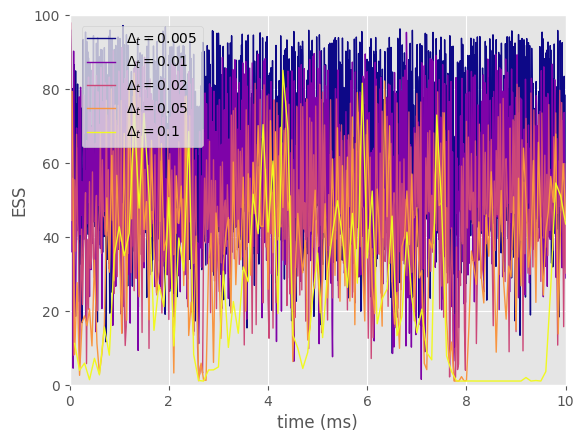

In [8]:
fig, ax = plt.subplots(1, 1)

cmap = plt.get_cmap('plasma', lut=5)
colors = [cmap(i) for i in range(5)]

for i in range(len(delta_t_vals)):
    subs_rate = subs_rates[i]
    x = sim_times[(subs_rate - 1)::subs_rate]
    y = guided_algs[i].summaries.ESSs
    ax.plot(x, y, color=colors[i], linewidth=1.0, linestyle='-', label=r'$\Delta_t = $' + str(delta_t_vals[i]))
    
ax.set(xlim=(0, 10), ylim=(0, 100), xlabel='time (ms)', ylabel='ESS')
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99))
    
plt.show()

# The same plots but with the filtering distributions on top:

In [23]:
w_arr_list = [np.stack([wgts.W for wgts in alg.hist.wgts]) for alg in guided_algs] # (M, N)
x_arr_list = [np.stack([X[X.dtype.names[-1]] for X in alg.hist.X]) for alg in bootstrap_algs] # (M, N, 2)


# Both of these are (M, 2)
means_list = [np.stack([np.average(X[:, :, 0], weights=W, axis=1), np.average(X[:, :, 1], weights=W, axis=1)], axis=1) for X, W in zip(x_arr_list, w_arr_list)]
# quantiles_list = [np.concatenate([np.quantile(X[:, :, 0], method='inverted_cdf', weights=W, axis=1), np.quantile(X[:, :, 1], method='inverted_cdf', weights=W, axis=1)]) for X, W in zip(x_arr_list, w_arr_list)]

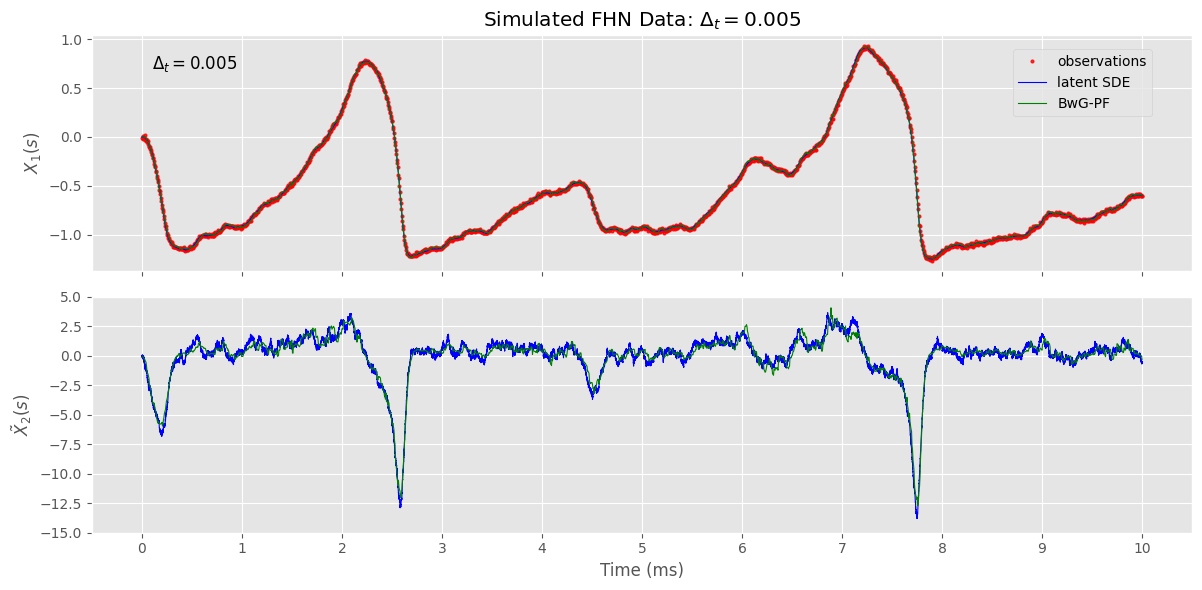

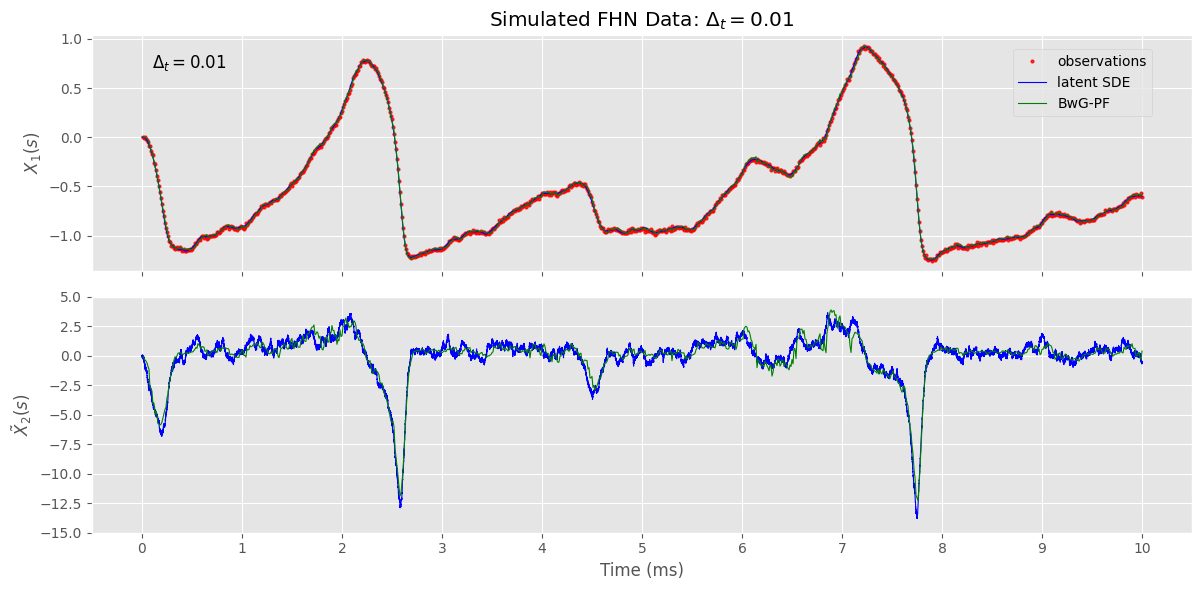

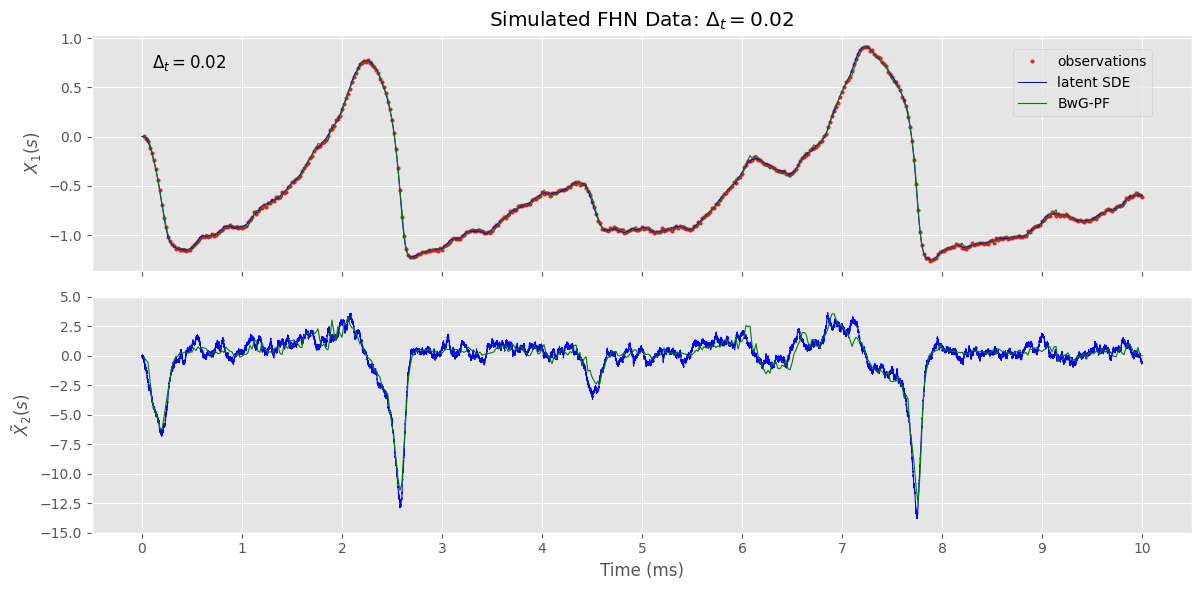

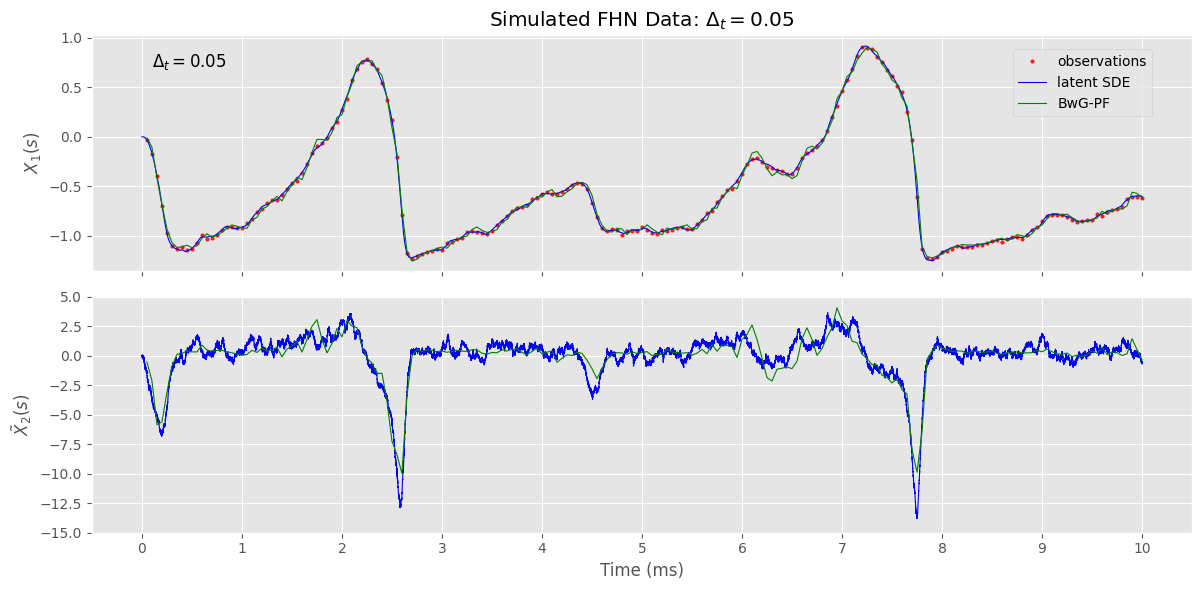

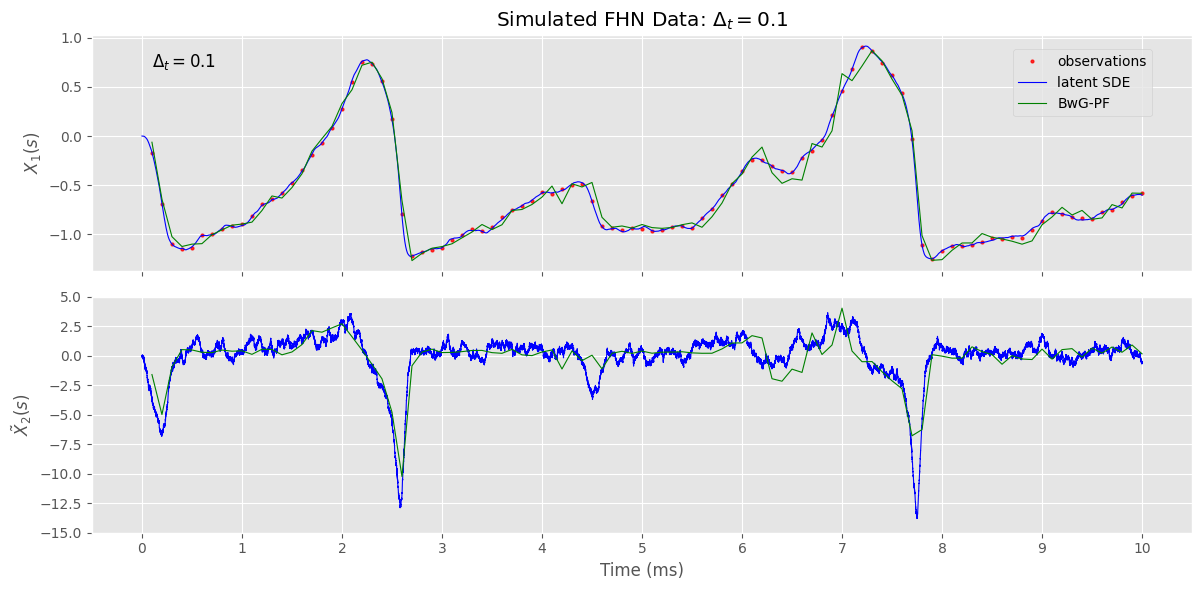

In [ ]:
for j, subs_rate, delta_t, obsvns in zip(range(len(delta_t_vals)), subs_rates, delta_t_vals, arr_observations_list):
    
    obs_times = sim_times[(subs_rate - 1)::subs_rate]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    labels = [r'$X_1(s)$', r'$\tilde{X}_2(s)$']

    # # chain_vals = icsmc_reparameterised.posterior['x'].values # (8, 1000, 100, 2)
    # # chain_vals = np.concatenate([chain_vals[i] for i in range(8)], axis=0)
    # mean_vals = chain_vals.mean(axis=0)
    # quantile_vals = np.quantile(chain_vals, axis=0, q=[0.05, 0.95])
    mean_vals = means_list[j]
    axes[0].plot(obs_times, obsvns, 'o', markersize=2.0, color='red', alpha=0.8, label='observations')

    for i, ax in enumerate(axes):
        ax.plot(sim_times, sde_paths[:, i], color='blue', linewidth=0.8, linestyle='-', marker=None, label='latent SDE')
        # ax.plot(obs_times, sde_paths[:, i], color='blue', linewidth=0.5, linestyle='-', marker=None, label='latent SDE')
        ax.plot(obs_times, mean_vals[:, i], color='green', linewidth=0.8, linestyle='-', marker=None, label='BwG-PF')
        # ax.plot(obs_times, quantile_vals[0, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6, label='95% C.I')
        # ax.plot(obs_times, quantile_vals[1, :, i], color='green', linewidth=0.6, linestyle='--', marker=None, alpha=0.6)
        ax.set_ylabel(labels[i])

    axes[0].set_title('Simulated FHN Data: '+ r'$\Delta_t =$' + str(delta_t))
    axes[0].text(0.1, 0.7, r'$\Delta_t =$' + str(delta_t), fontsize=12)
    axes[0].legend(loc='upper right', bbox_to_anchor=(0.97, 0.97))

    axes[-1].set_xlabel('Time (ms)')
    axes[-1].set_xticks([float(i) for i in range(11)])
    axes[-1].set_ylim((-15.0, 5.0))

    # axes[-1].set_xlim((0, 1.5))
    # axes[-1].set_ylim((-5.0, 5.0))

    plt.tight_layout()
    plt.show()

# Visualisation of the particle filter run:

## Single Step Visualisation

NameError: name 'observations' is not defined

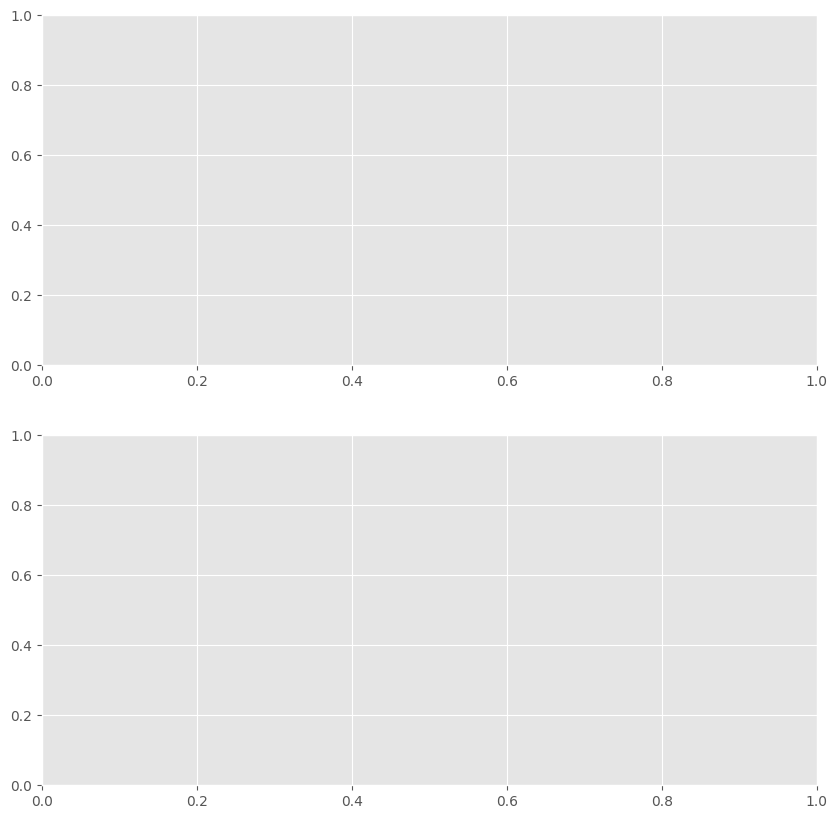

In [ ]:
num=100; N=1000
start_time = 7.6
end_time = start_time + cdssm.s_ts

times = np.linspace(start=start_time, stop=end_time, num=(num+1))
sim_times = np.linspace(start=start_time, stop=end_time, num=1001)

t = int(start_time / cdssm.s_ts)
smc = CDSSM_SMC(cd_fk, N=N, num=num, store_history=True)

for _ in range(t+1):
    smc.next()

Xp = smc.Xp; X = smc.X; W = smc.W

x_start = Xp[Xp.dtype.names[-1]] if Xp is not None else np.concatenate([cdssm.x0]*N, axis=0)
X_arr = np.stack([x_start] + [X[name] for name in X.dtype.names], axis=2)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

if t != 0:
    axes[0].plot([start_time, end_time], observations[t-1:(t+1)], 'o', color='red', markersize=3.0)
else:
    axes[0].plot([end_time], observations[0], 'o', color='red', markersize=3.0)

for i in range(2):
    axes[i].plot(times, X_arr[:, i].T, color='green', linewidth=0.5, linestyle='-', alpha=0.1, label='particles')
    axes[i].plot(sim_times, sde_paths[(1000)*t:((1000)*(t+1)+1), i].T, color='blue', linewidth=1.0, linestyle='-', label='')

# axes[0].set_xlabel()
plt.show()